# 1. Setup and upload data

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


In [47]:
path = 'default credit.csv'

df = pd.read_csv(path)
data = df.copy()
data

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,BILL_AMT_avg,BILL_AMT_trend,credit utilization ratio
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,689,0,0,0,0,1,1284.000000,3913,0.195650
1,120000,2,2,2,26,-1,2,0,0,0,...,0,1000,1000,1000,0,2000,1,2846.166667,-579,0.022350
2,90000,2,2,2,34,0,0,0,0,0,...,1518,1500,1000,1000,1000,5000,0,16942.166667,13690,0.324878
3,50000,2,2,1,37,0,0,0,0,0,...,2000,2019,1200,1100,1069,1000,0,38555.666667,17443,0.939800
4,50000,1,2,1,57,-1,0,-1,0,0,...,2000,36681,10000,9000,689,679,0,18223.166667,-10514,0.172340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29960,220000,1,3,1,39,0,0,0,0,0,...,8500,20000,5003,3047,5000,1000,0,120891.500000,172968,0.858855
29961,150000,1,3,2,43,-1,-1,-1,-1,0,...,1837,3526,8998,129,0,0,0,3530.333333,1683,0.011220
29962,30000,1,2,2,37,4,3,2,-1,0,...,0,0,22000,4200,2000,3100,1,11749.333333,-15792,0.118833
29963,80000,1,3,1,41,1,-1,0,0,0,...,85900,3409,1178,1926,52964,1804,1,44435.166667,-50589,-0.020563


# 2. Feature Engineering

In [48]:
nominal_features = ['SEX', 'EDUCATION', 'MARRIAGE']    # no natural order -> one-hot encode
ordinal_features = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']  # higher = more delayed = worse
con_features = ['AGE', 'LIMIT_BAL', 'BILL_AMT_avg', 'BILL_AMT_trend', 'credit utilization ratio',
                  'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
target = 'default payment next month'

In [49]:
# log transformation for right-skewed data
def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))

skewed_nonneg = ['AGE', 'LIMIT_BAL'] + [f'PAY_AMT{i}' for i in range(1, 7)]
skewed_signed = ['BILL_AMT_avg', 'BILL_AMT_trend', 'credit utilization ratio']  

for col in skewed_nonneg:
    data[col] = np.log1p(data[col])
for col in skewed_signed:
    data[col] = signed_log1p(data[col])

<Axes: >

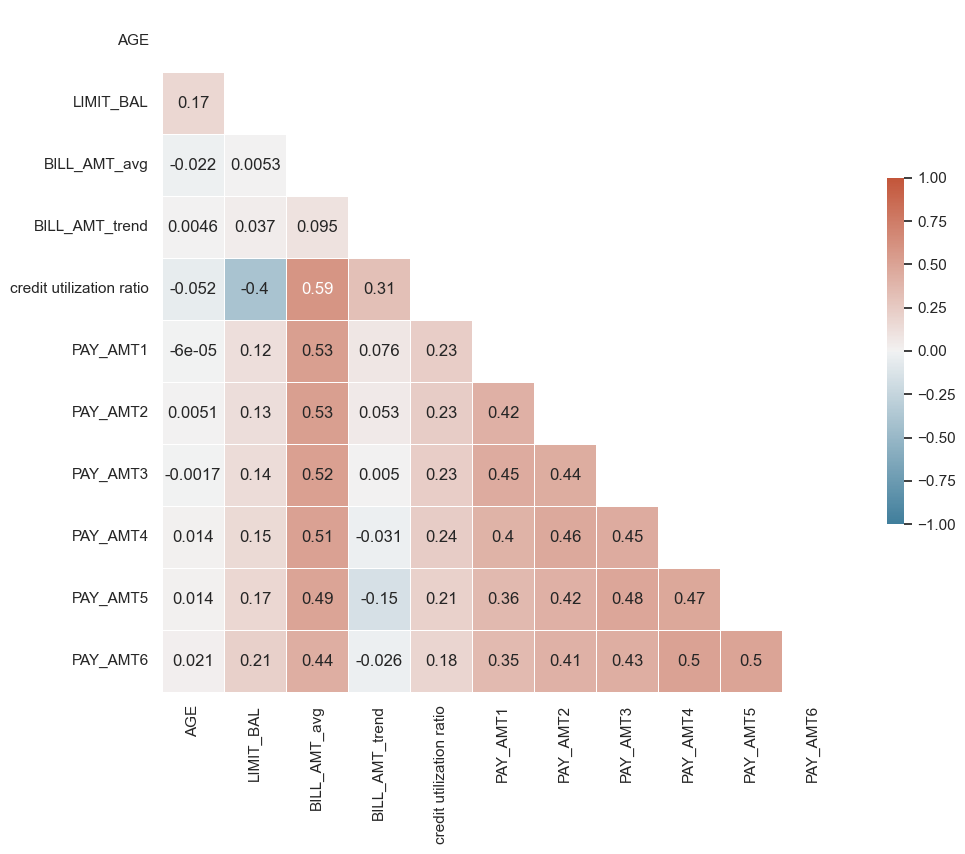

In [50]:
sns.set_theme(style="white")

# Compute the correlation matrix
corr = data[con_features].corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True)

In [51]:
X = data[ordinal_features + con_features + nominal_features]
y = data[target]

X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid, y_train_valid, test_size=0.25, random_state=42
)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), ordinal_features + con_features),
    ('nom', OneHotEncoder(drop='first', handle_unknown='ignore'), nominal_features),
])
X_train_scaled = preprocessor.fit_transform(X_train)
X_valid_scaled = preprocessor.transform(X_valid)
X_test_scaled = preprocessor.transform(X_test)

feature_names = [name.split('__', 1)[1] for name in preprocessor.get_feature_names_out()]

# 3. Training

In [52]:
param_grid = {
    'learning_rate': [0.001, 0.01, 0.1],
    'max_depth': [2, 3, 5],
    'n_estimators': [100, 200, 300],

}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [53]:
grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(),
    param_grid=param_grid,
    scoring='neg_log_loss', # instead of roc_auc
    cv=cv,
    n_jobs= -1,
)
grid_search.fit(X_train_scaled, y_train)

print('Best params:', grid_search.best_params_)
print('Best CV log loss:', -grid_search.best_score_)

Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV log loss: 0.42866286720829894


In [54]:
model = grid_search.best_estimator_

y_valid_pred = model.predict(X_valid_scaled)
y_valid_proba = model.predict_proba(X_valid_scaled)[:,1]

Text(0.5, 1.0, 'Precision and Recall vs. Threshold')

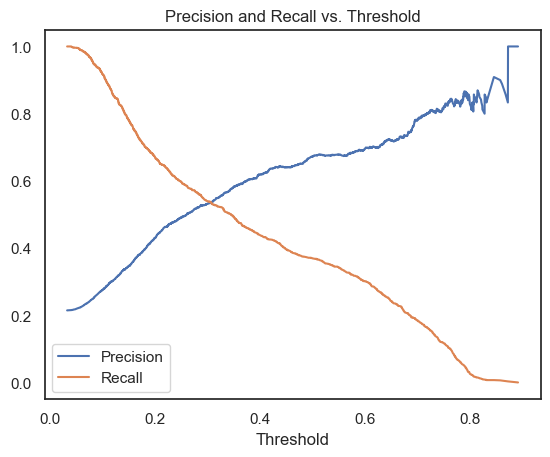

In [55]:
precision, recall, thresholds = precision_recall_curve(y_valid, y_valid_proba)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision and Recall vs. Threshold')

In [56]:
fn_cost, fp_cost = 4, 1  # illustrative — replace with a defensible ratio
thresholds = np.arange(0.05, 0.95, 0.01)
costs = []
for t in thresholds:
    pred = (y_valid_proba >= t).astype(int)
    fn = ((pred==0) & (y_valid==1)).sum()
    fp = ((pred==1) & (y_valid==0)).sum()
    costs.append(fn*fn_cost + fp*fp_cost)

best_threshold = thresholds[np.argmin(costs)]
print(f'Best threshold based on cost of FN and FP: {best_threshold}')

Best threshold based on cost of FN and FP: 0.22000000000000003


# 4. Evaluation

In [57]:
y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4667
           1       0.66      0.37      0.47      1326

    accuracy                           0.82      5993
   macro avg       0.75      0.66      0.68      5993
weighted avg       0.80      0.82      0.80      5993



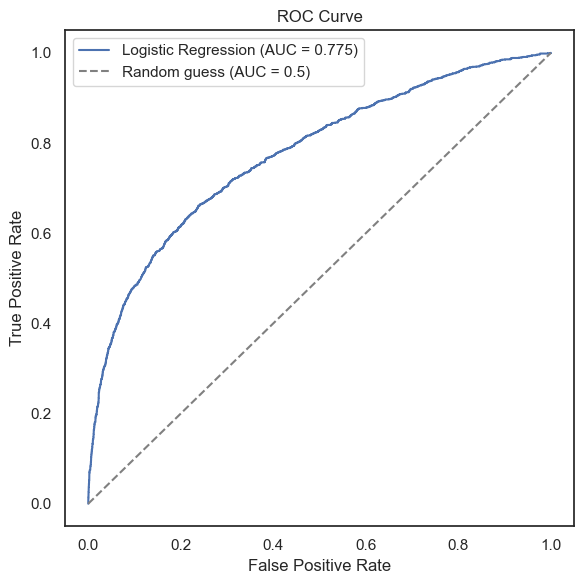

In [ ]:
y_proba = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'Gradient Boosting (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()

In [59]:

pred = (y_proba >= best_threshold).astype(int)
print(f'Cost optimal {best_threshold}')
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, digits=3))

Cost optimal 0.22000000000000003
[[3697  970]
 [ 496  830]]
              precision    recall  f1-score   support

           0      0.882     0.792     0.835      4667
           1      0.461     0.626     0.531      1326

    accuracy                          0.755      5993
   macro avg      0.671     0.709     0.683      5993
weighted avg      0.789     0.755     0.767      5993



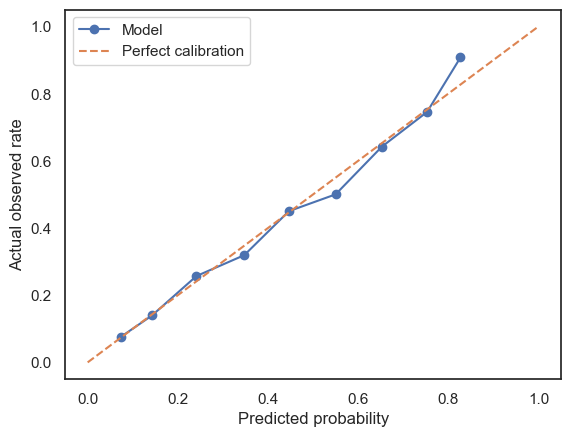

In [60]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')
plt.xlabel('Predicted probability')
plt.ylabel('Actual observed rate')
plt.legend()